## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import logging

import msml610_utils as ut

ut.config_notebook()

# Initialize logger.
logging.basicConfig(level=logging.INFO)
_LOG = logging.getLogger(__name__)

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
vim support installed: restart the notebook, if needed


Python 3.12.3
Linux 7d77d2247121 6.12.67-linuxkit #1 SMP Sun Jan 25 02:26:28 UTC 2026 aarch64 aarch64 aarch64 GNU/Linux


In [2]:
import helpers.hio as hio
import L09_05_02_kalman_filter_utils as time_ut

dst_dir = "figures"
hio.create_dir(dst_dir, incremental=True)
# cp msml610/tutorials/figures/*.png msml610/lectures_source/figures

# Cell 1: Sum and Product of Gaussians

In [3]:
x = time_ut.Gaussian(3.4, 10.1)
print(x)
print("x.mean=", x.mean)
print("x.var=", x.var)

N(mu=3.400, sigma^2=10.100)
x.mean= 3.4
x.var= 10.1


## Cell 1.1: Sum of Gaussians
- Given two Gaussians $X$ and $Y$
  $$X \sim Normal(\mu_1, \sigma_1^2)$$
  $$Y \sim Normal(\mu_2, \sigma_2^2)$$
- For correlated Gaussians with correlation coefficient $\rho$, the sum
  $Z = X + Y$ is a Gaussian $Normal(\mu, \sigma^2)$ with:
  $$\mu = \mu_1 + \mu_2$$
  $$\sigma^2 = \sigma_1^2 + \sigma_2^2 + 2\rho\sigma_1\sigma_2$$
- **Interpretation:**
  - The mean is the sum of the means (by linearity)
  - For independent Gaussians ($\rho = 0$), the variance is the sum of
    variances (uncertainty increases)
  - Positive correlation increases variance, negative correlation decreases it

In [5]:
# Sum two Gaussians.
x = time_ut.Gaussian(10, 0.2**2)
y = time_ut.Gaussian(15, 0.7**2)

z = time_ut.gaussian_sum(x, y)
print(z)

N(mu=25.000, sigma^2=0.530)


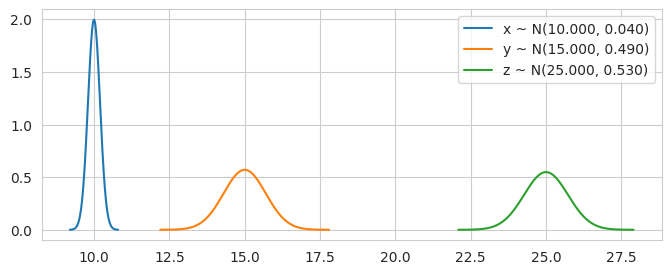

In [6]:
ax = time_ut.plot_gaussian(x, label="x")
time_ut.plot_gaussian(y, ax=ax, label="y")
time_ut.plot_gaussian(z, ax=ax, label="z");

In [7]:
# Interactive exploration of sum of Gaussians with correlation.
time_ut.cell1_1_plot_gaussian_sum()

## Cell 1.2: Product of Gaussians
- Given two Gaussians $X$ and $Y$
  $$X \sim Normal(\mu_X, \sigma_X^2)$$
  $$Y \sim Normal(\mu_Y, \sigma_Y^2)$$
- The product $Z = X \cdot Y$ (PDF multiplication) is a Gaussian
  $Normal(\mu_Z, \sigma_Z^2)$ with:
  $$\mu_Z = \frac{\mu_X \sigma_Y^2 + \mu_Y \sigma_X^2}{\sigma_X^2 + \sigma_Y^2}$$
  $$\sigma_Z^2 = \frac{\sigma_X^2 \sigma_Y^2}{\sigma_X^2 + \sigma_Y^2}$$
- **Interpretation:**
  - Reduces variance by incorporating more information
  - If one Gaussian $X$ is narrower (more accurate), result leans towards $X$
  - If two Gaussians are similar (measures corroborate), result becomes more
    certain

**Gaussian products in terms of precision**

- The precision of a Gaussian is
  $$\tau = \frac{1}{\sigma^2}$$
- The precision of the product is the sum of the precisions
  $$\tau_Z = \tau_X + \tau_Y$$
  $$\sigma_Z^2 = \frac{1}{\frac{1}{\sigma_X^2} + \frac{1}{\sigma_Y^2}}$$
- The mean is the average of the means weighted by the precisions
  $$\mu_Z = \sigma_Z^2 (\frac{\mu_X}{\sigma_X^2} + \frac{\mu_Y}{\sigma_Y^2})$$

- The mean is averaged towards the more certain Gaussian
- The variance is smaller than both

In [8]:
# Product of two equal Gaussians.
x = time_ut.Gaussian(10, 1.0)

z = time_ut.gaussian_multiply(x, x)
print(z)

# The result is more certain than both.

N(mu=10.000, sigma^2=0.500)


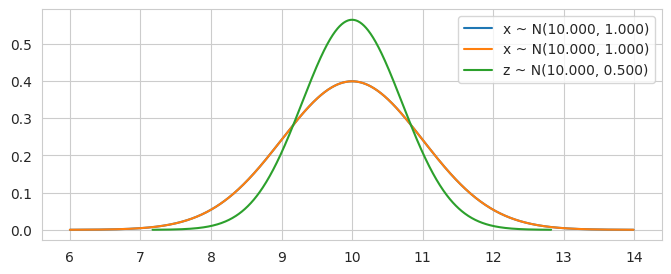

In [9]:
ax = time_ut.plot_gaussian(x, label="x")
time_ut.plot_gaussian(x, ax=ax, label="x")
time_ut.plot_gaussian(z, ax=ax, label="z");

N(mu=10.377, sigma^2=0.037)


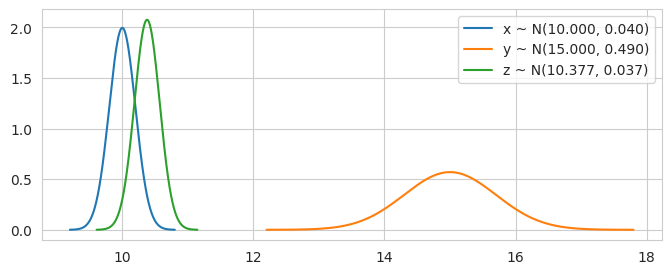

In [11]:
# Product of two different Gaussians.
x = time_ut.Gaussian(10, 0.2**2)
y = time_ut.Gaussian(15, 0.7**2)

z = time_ut.gaussian_multiply(x, y)
print(z)

ax = time_ut.plot_gaussian(x, label="x")
time_ut.plot_gaussian(y, ax=ax, label="y")
time_ut.plot_gaussian(z, ax=ax, label="z");

N(mu=9.950, sigma^2=0.500)


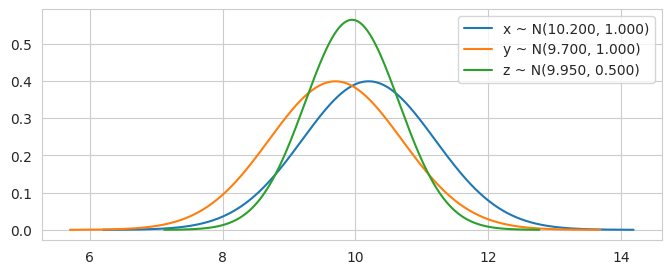

In [12]:
x = time_ut.Gaussian(10.2, 1)
y = time_ut.Gaussian(9.7, 1)

z = time_ut.gaussian_multiply(x, y)
print(z)

ax = time_ut.plot_gaussian(x, label="x")
time_ut.plot_gaussian(y, ax=ax, label="y")
time_ut.plot_gaussian(z, ax=ax, label="z");

In [14]:
# Interactive exploration of product of Gaussians.
time_ut.cell1_2_plot_gaussian_product()

# Cell 2: Tracking the Dog

- The intuition is the same as the discrete case

- There is a cycle of prediction and updates
    1) Predict: prior = x_est using system model
    2) Update: posterior = likelihood * prior

- Create prior (using current estimate and system model)
  - `prior = predict(x, process_model)`
- Create likelihood (using measurement)
  - `likelihood = gaussian(z, sensor_var)`
- Update belief using prior and likelihood
  - `x = update(prior, likelihood)`

- Sum adds uncertainty
- Multiplication reduces uncertainty

- Let's assume that the dog moves in the hallway, back and forth
  - It's not circular
- We have a sensor that measures the distance of the dog from one extreme

We can use Newton's equation of motion to compute the position of the dog,
based on current position and velocity

$$\overline{x}_k = x_{k-1} + v_k \Delta_t$$

- $x_{k-1}$ has uncertainty quantified by a Gaussian
- $v_k$ has also uncertainty quantified by a Gaussian

We can compute the sum of two Gaussians in terms of mean and uncertainty
- It makes sense since we know that uncertainty becomes larger

- The likelihood $z | x$ is the probability of measures given the current
  state



In [36]:
import numpy as np
np.random.seed(13)

# Variance in the dog's movement.
process_var = 1.0
# Variance in the sensor.
sensor_var = 2.0

# Dog's initial position.
x = time_ut.Gaussian(0.0, 20.0**2)
velocity = 1.0
# Time step in seconds.
dt = 1.0
# Displacement to add to x (representing how to model the movement of the dog).
process_model = time_ut.Gaussian(velocity * dt, process_var)

# Simulate dog and get measurements.
dog = time_ut.DogSimulation(
    x0=x.mean,
    velocity=process_model.mean,
    measurement_var=sensor_var,
    process_var=process_model.var)

# Create a list of measurements.
n_steps = 10
zs = [dog.move_and_sense() for _ in range(n_steps)]
print(zs)

[1.3535959735108178, 1.8820653967131618, 4.341047429453569, 7.156332673205118, 6.938695089418526, 6.843912342028484, 9.846824080052299, 12.553482049375292, 16.2730841073834, 14.800411177015299]


In [37]:
# Perform Kalman filter on measurement z.
info = []
for z in zs:
    prior = time_ut.predict(x, process_model)
    likelihood = time_ut.Gaussian(z, sensor_var)
    x = time_ut.update(prior, likelihood)
    #
    info.append((prior, x, z))

print(time_ut.kf_info_to_df(info))

   predict_x  predict_var          z   update_x  update_var
0   1.000000   401.000000   1.353596   1.351841    1.990074
1   2.351841     2.990074   1.882065   2.070349    1.198409
2   3.070349     2.198409   4.341047   3.735724    1.047258
3   4.735724     2.047258   7.156333   5.960160    1.011677
4   6.960160     2.011677   6.938695   6.949397    1.002911
5   7.949397     2.002911   6.843912   7.396253    1.000727
6   8.396253     2.000727   9.846824   9.121670    1.000182
7  10.121670     2.000182  12.553482  11.337631    1.000045
8  12.337631     2.000045  16.273084  14.305380    1.000011
9  15.305380     2.000011  14.800411  15.052895    1.000003


- The uncertainty after prediction is > than the uncertainty after update (as usual)
- The variance of the prior at time 0 is very large, but after we measure, the
    variance of the measurement "dominates" (i.
- The posterior values are always between the measurement and the prior
- After a few cycles the posterior variance is around 1, which is smaller than the sensor variance ~2
  - Using a model + measurements is better

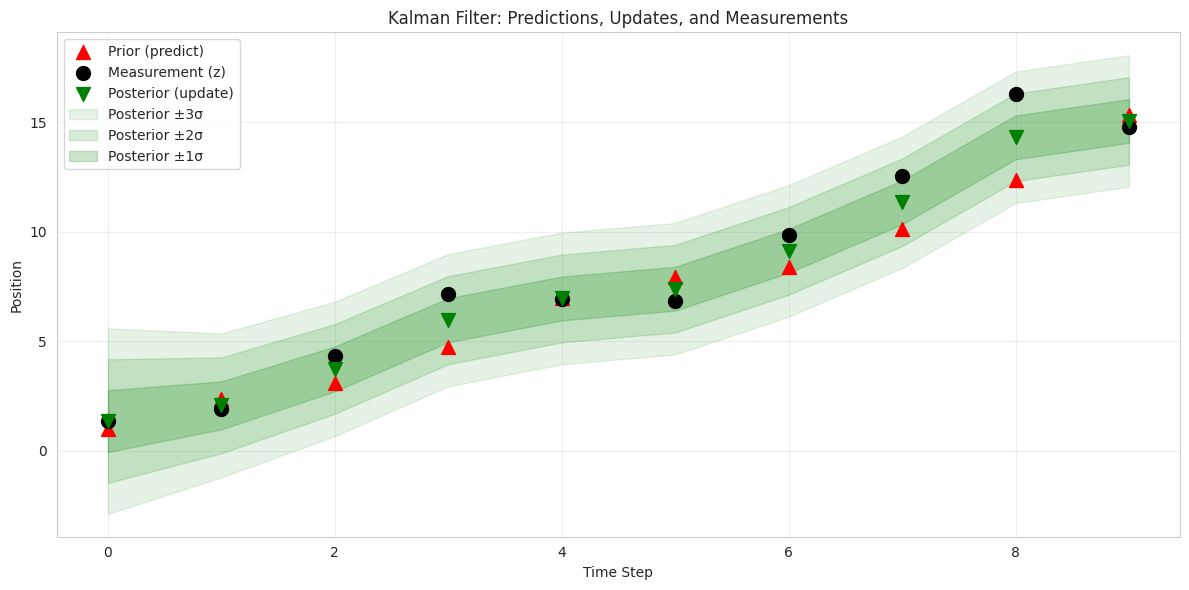

In [38]:
# Plot Kalman filter results.
time_ut.plot_kf_info(info)

In [40]:
# Interactive Dog simulation with adjustable parameters.
time_ut.cell3_interactive_dog_simulation()

- Is it better to have precise measurements (`sensor_var` << `process_var`) or vice versa?